# Morphological profiling

This notebook measures cell shape from the same StarDist masks used for fluorescence. It focuses on CD206, then compares treatment-level morphology changes to M0 and plots the CD206 brightness / cell-area cloud with robust median markers.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from IPython.display import display

import macrophage_analysis as ma

morphology_donors = list(ma.DEFAULT_DONORS)
morphology_conditions = list(ma.DEFAULT_CONDITIONS)
morphology_antibody = "CD206"
morphology_n_tiles = (8, 8)

morphology_donors, morphology_conditions, morphology_antibody

(['D45', 'D47'],
 ['M0',
  'B68KCP2',
  'B75palmFP1',
  'M130227Ni',
  'M130429Np',
  'T12CMNepiP4',
  'T8CMNdermP6'],
 'CD206')

Run this once. It only analyzes CD206 to keep the morphology profiling pass focused and faster than the full five-marker batch.

In [2]:
morphology_results = ma.extract_single_cell_fluorescence(
    donors=morphology_donors,
    conditions=morphology_conditions,
    antibody_order=[morphology_antibody],
    n_tiles=morphology_n_tiles,
)

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Analyzing CD206...


100%|██████████| 64/64 [00:02<00:00, 24.24it/s]


Finished analyzing 14 donor / treatment / antibody combinations.


First, summarize the treatment-level shifts per donor as Log2 fold change compared to that donor's M0.

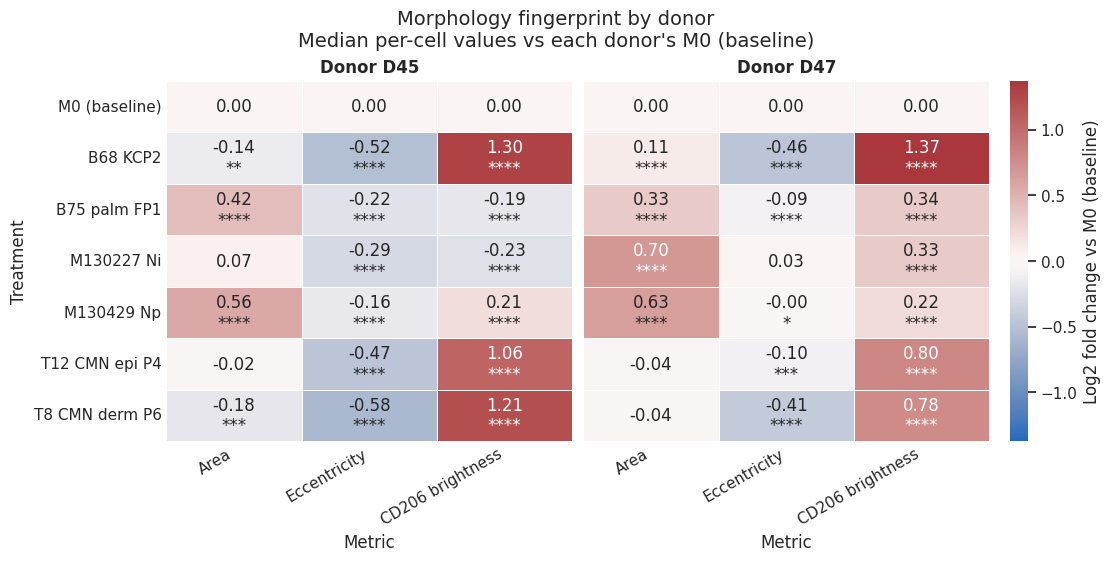

,donor_label,condition_label,log2_fc_area,stars_area,log2_fc_eccentricity,stars_eccentricity,log2_fc_cd206_brightness,stars_cd206_brightness
0,Donor D45,M0 (baseline),0.00,baseline,0.00,baseline,0.00,baseline
1,Donor D45,B68 KCP2,-0.14,**,-0.52,****,1.30,****
2,Donor D45,B75 palm FP1,0.42,****,-0.22,****,-0.19,****
3,Donor D45,M130227 Ni,0.07,ns,-0.29,****,-0.23,****
4,Donor D45,M130429 Np,0.56,****,-0.16,****,0.21,****
5,Donor D45,T12 CMN epi P4,-0.02,ns,-0.47,****,1.06,****
6,Donor D45,T8 CMN derm P6,-0.18,***,-0.58,****,1.21,****
7,Donor D47,M0 (baseline),0.00,baseline,0.00,baseline,0.00,baseline
8,Donor D47,B68 KCP2,0.11,****,-0.46,****,1.37,****
9,Donor D47,B75 palm FP1,0.33,****,-0.09,****,0.34,****


In [3]:
morphology_fold_changes = ma.plot_morphology_heatmap(
    morphology_results,
    antibody=morphology_antibody,
    summary_stat="median",
    per_donor=True,
)

morphology_fold_change_display = morphology_fold_changes[
    [
        "donor_label",
        "condition_label",
        "log2_fc_area",
        "stars_area",
        "log2_fc_eccentricity",
        "stars_eccentricity",
        "log2_fc_cd206_brightness",
        "stars_cd206_brightness",
    ]
]

display(
    morphology_fold_change_display.round(
        {
            "log2_fc_area": 2,
            "log2_fc_eccentricity": 2,
            "log2_fc_cd206_brightness": 2,
        }
    )
)

Then, show the cell-level relationship directly, split by donor: CD206 brightness on the X-axis and cell area on the Y-axis. Faint points are sampled cells; large markers are treatment medians.

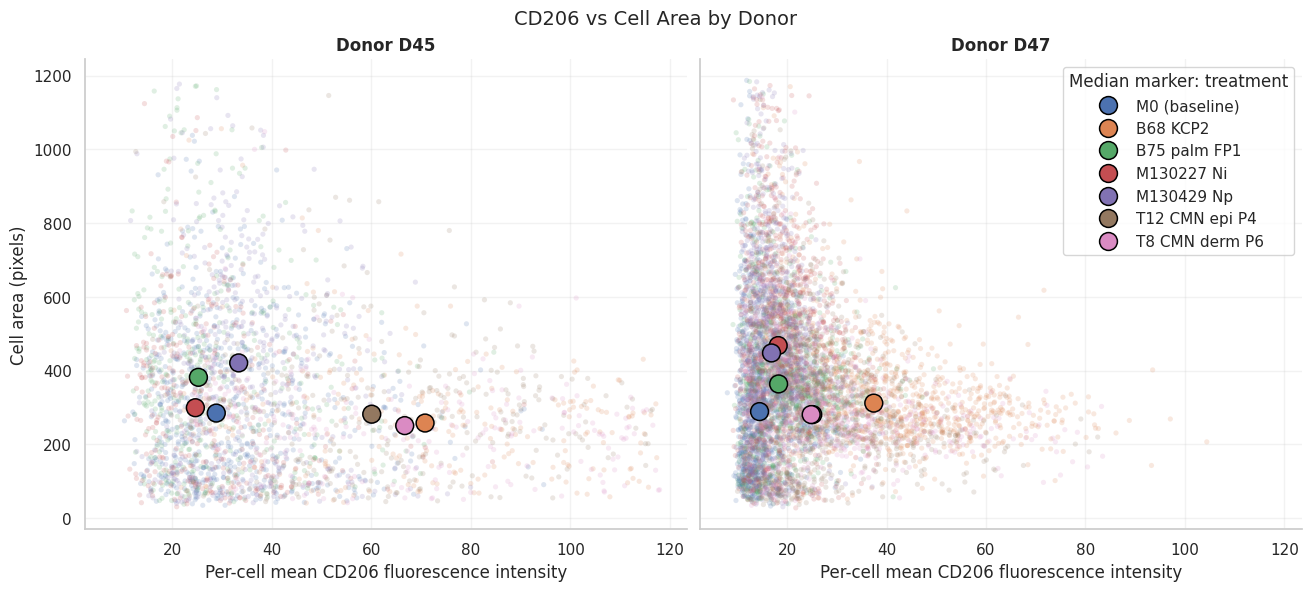

In [4]:
morphology_cells = ma.plot_area_intensity_scatter(
    morphology_results,
    antibody=morphology_antibody,
    max_points_per_group=1000,
    intensity_upper_percentile=99.0,
    area_upper_percentile=99.0,
    split_by_donor=True,
)

Optional QC table: robust medians by condition and donor. Use the scatter plot above for interpretation.

In [5]:
morphology_summary = ma.build_morphology_summary_table(
    morphology_results,
    antibody=morphology_antibody,
)

display(
    morphology_summary.round(
        {
            "median_intensity": 2,
            "median_area": 1,
            "median_eccentricity": 3,
        }
    )
)

,condition,condition_label,donor,donor_label,cell_count,median_intensity,median_area,median_eccentricity
0,M0,M0 (baseline),D45,Donor D45,643,28.83,285.0,0.842
1,M0,M0 (baseline),D47,Donor D47,1844,14.47,289.0,0.726
2,B68KCP2,B68 KCP2,D45,Donor D45,311,70.81,258.0,0.586
3,B68KCP2,B68 KCP2,D47,Donor D47,1047,37.44,312.0,0.528
4,B75palmFP1,B75 palm FP1,D45,Donor D45,421,25.24,382.0,0.725
5,B75palmFP1,B75 palm FP1,D47,Donor D47,1875,18.30,364.0,0.681
6,M130227Ni,M130227 Ni,D45,Donor D45,318,24.63,299.5,0.689
7,M130227Ni,M130227 Ni,D47,Donor D47,1103,18.22,468.0,0.739
8,M130429Np,M130429 Np,D45,Donor D45,382,33.34,421.0,0.753
9,M130429Np,M130429 Np,D47,Donor D47,1460,16.88,448.0,0.725
